# Kaggle: fraud detection exercise

In [1]:
import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import average_precision_score # , classification_report
from sklearn.metrics import precision_recall_curve  #, PrecisionRecallDisplay
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder


# Terminal: start the tracking server (or just `mlflow ui` for the lightweight version)
# mlflow ui --host 0.0.0.0 --port 5000

.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("kaggle_fraud_ex2")

# autolog() is the magic
# it auto-captures params, the model, and training metrics. 
# You manually log_metric only for test-set stuff autolog can't see. 
# Each with mlflow.start_run() block is one row in the UI.
mlflow.xgboost.autolog()

In [3]:
train = pd.read_csv('mlflow/kaggle_fraud_classifier/data/fraudTrain.csv')

In [4]:
test = pd.read_csv('mlflow/kaggle_fraud_classifier/data/fraudTest.csv')

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
train.groupby(['is_fraud']).agg(
    n_total=('is_fraud', 'size'),
    n_fraud=('is_fraud', 'sum'))

,n_total,n_fraud
is_fraud,,
0,1289169,0
1,7506,7506


# Feature engineering

In [8]:
# Tag and combine so test sees real train history per card                                                                                                                                                                                     
df = pd.concat([train.assign(_split='train'), test.assign(_split='test')], ignore_index=True)
df = df.sort_values(['cc_num', 'unix_time']).reset_index(drop=True)                                                                                                                                                                            
                                                                                                                                                                                                                                                
# Simple datetime-derived features                                                                                                                                                                                                             
ts = pd.to_datetime(df['trans_date_trans_time'])                                                                                                                                                                                               
df['hour']      = ts.dt.hour                              
df['dayofweek'] = ts.dt.dayofweek                                                                                                                                                                                                              
df['day']       = ts.dt.day
df['age']       = (ts - pd.to_datetime(df['dob'])).dt.days / 365                                                                                                                                                                               
                                                                                                                                                                                                                                                
g = df.groupby('cc_num', sort=False)
                                                                                                                                                                                                                                                
# Amount vs running mean of this card (shift(1) to exclude current row, no leakage)                                                                                                                                                            
df['amt_vs_card_mean'] = df['amt'] / g['amt'].transform(lambda s: s.shift(1).expanding().mean())
                                                                                                                                                                                                                                                
# Seconds since previous transaction                                                                                                                                                                                                           
df['time_since_last_tx'] = g['unix_time'].diff()                                                                                                                                                                                               
                                                                                                                                                                                                                                                
# Haversine to previous merchant location                 
def haversine(lat1, lon1, lat2, lon2):
    R = 6371                                                                                                                                                                                                                                   
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)                                                                                                                                                                                                             
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2                                                                                                                                            
    return 2 * R * np.arcsin(np.sqrt(a))                                                                                                                                                                                                       
                                                                                                                                                                                                                                                
df['distance_from_prev'] = haversine(                                                                                                                                                                                                          
    g['merch_lat'].shift(1), g['merch_long'].shift(1),    
    df['merch_lat'],         df['merch_long']                                                                                                                                                                                                  
)                                                                                                                                                                                                                                              

# 30d rolling spend and count per card, using seconds since last (30 days = 2_592_000 s)                                                                                                                                                       
df['30d_spend_amt'] = g['amt'].transform(lambda s: s.shift(1).rolling(50, min_periods=1).sum())                                                                                                                                                
df['30d_num_tx']    = g['amt'].transform(lambda s: s.shift(1).rolling(50, min_periods=1).count())     

# 1. Distance from cardholder's home (you have lat/long of customer AND merchant)
df['distance_from_home'] = haversine(df['lat'], df['long'], df['merch_lat'], df['merch_long'])                                                                                                                                                 
                                                                                                                                                                                                                                
# 2. Cyclical hour encoding (fraud peaks at night)                                                                                                                                                                                             
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)                                                                                                                                                                                                 
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)                                                                                                                                                                                                 
                                                                                                                                                                                                                                
# 3. Amount as fraction of recent spend (z-score-ish)
df['amt_vs_recent_spend'] = df['amt'] / (df['30d_spend_amt'] + 1)                                                                                                                                                                              
                                                                                                                                                                                                                                
# 4. Is night transaction (binary, captures the 22-04 window XGBoost would otherwise have to discover)                                                                                                                                         
df['is_night'] = df['hour'].between(22, 23) | df['hour'].between(0, 4)                                                                                                                                                                         
df['is_night'] = df['is_night'].astype(int)                                                                                                                                                                                                    
                                                                                                                                                                                                                            
# 5. Velocity: txns in the last hour for this card                                                                                                                                                                                             
df['1h_num_tx'] = g['amt'].transform(lambda s: s.shift(1).rolling(5, min_periods=1).count())                                                                                                                                                 
# (fixed window, proxy for "burst of activity")                                                                                                                                                                                                
                                                                                                                                                                                                                                
# 6. Log-amount (heavy right tail in transactions)                                                                                                                                                                                             
df['log_amt'] = np.log1p(df['amt'])  

# Split back                                                                                                                                                                                                                                   
train_fe = df[df['_split'] == 'train'].drop(columns='_split')                                                                                                                                                                                
test_fe  = df[df['_split'] == 'test'].drop(columns='_split')

In [9]:
# removing features which are not informative
drop_list = ['Unnamed: 0', 'cc_num', 'trans_num', 'street', 'first', 'last', 'dob', 'trans_date_trans_time', 'unix_time']

In [10]:
y_train = train_fe['is_fraud']
X_train = train_fe.drop(columns=drop_list+['is_fraud'])

In [11]:
X_train.select_dtypes(include='object').nunique().sort_values(ascending=False)

city        894
merchant    693
job         494
state        51
category     14
gender        2
dtype: int64

In [12]:
print(np.round((1289169+7506)/7506, 2))

172.75


In [13]:
cat_cols = X_train.select_dtypes(include='object').columns.to_list()
cat_cols

['merchant', 'category', 'gender', 'city', 'state', 'job']

In [14]:
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')

In [15]:
encoder = TargetEncoder(target_type='binary', smooth='auto', cv=5)

In [16]:
X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)

# Train & Predict

In [17]:
# dropping columns
y_test = test_fe['is_fraud']
X_test = test_fe.drop(columns=drop_list+['is_fraud'])

# categories
for col in cat_cols:
    X_test[col] = X_test[col].astype('category')

X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [20]:
for n_est in [1500, 2000]:
    for max_d in [15, 20]:
        for l_rate in [0.15, 0.3]:
            for pos_weight in [10, 25]:
                with mlflow.start_run(run_name=f"xgb_n{n_est}_d{max_d}_l{l_rate}_pos{pos_weight}"):
                    clf = xgb.XGBClassifier(n_estimators=n_est, max_depth=max_d
                                            , learning_rate=l_rate, scale_pos_weight=pos_weight
                                            , objective='binary:logistic',  eval_metric='aucpr'
                                            , n_jobs=-1 # this ensures we use all CPU cores on my Mac
                    )
                    clf.fit(X_train, y_train)

                    proba = clf.predict_proba(X_test)[:, 1]
                    ap = average_precision_score(y_test, proba) # that's the key metric to report on
                    precision, recall, thresholds = precision_recall_curve(y_test, proba) # second key metric
                    f1 = 2 * precision * recall / (precision + recall + 1e-9)
                    best = f1.argmax() # get's the index of the best f1 which is a function of precision and recall
                    best_f1, best_thresh = f1[best], thresholds[best]

                    mlflow.log_metric("pr_auc_test", ap)
                    mlflow.log_metric("f1_at_best_thres", best_f1)
                    mlflow.log_param("best_threshold", best_thresh)


2026/05/11 09:30:04 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: ".venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/11 09:30:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 09:30:14 WARNING mlflow.utils.autologging_utils:

🏃 View run xgb_n1500_d15_l0.15_pos10 at: http://localhost:5000/#/experiments/2/runs/55078fa284b54273a891d49159435963
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/11 09:30:51 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: ".venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/11 09:30:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 09:31:00 WARNING mlflow.utils.autologging_utils:

🏃 View run xgb_n1500_d15_l0.15_pos25 at: http://localhost:5000/#/experiments/2/runs/0e3b9886107b41ce98bd50076f20bd6e
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/11 09:31:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: ".venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/11 09:31:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 09:31:40 WARNING mlflow.utils.autologging_utils:

...

🏃 View run xgb_n2000_d20_l0.15_pos25 at: http://localhost:5000/#/experiments/2/runs/2e95f44942d34157b725518f0931ac60
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/11 09:40:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: ".venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/11 09:40:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 09:41:02 WARNING mlflow.utils.autologging_utils:

🏃 View run xgb_n2000_d20_l0.3_pos10 at: http://localhost:5000/#/experiments/2/runs/02ab140078644175ae025e0609573091
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/11 09:41:40 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: ".venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/11 09:41:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 09:41:49 WARNING mlflow.utils.autologging_utils:

🏃 View run xgb_n2000_d20_l0.3_pos25 at: http://localhost:5000/#/experiments/2/runs/3a1102c722aa4805a21de2b83d263bd7
🧪 View experiment at: http://localhost:5000/#/experiments/2


# Solution
500 trees, 12 max depths, 0.3 lr and 25 positive weight

In [22]:
best_clf = xgb.XGBClassifier(
        n_estimators=500
        , max_depth=12
        , learning_rate=0.3
        , scale_pos_weight=25
        , objective='binary:logistic'
        , eval_metric='aucpr'
        , n_jobs=-1
)

best_clf.fit(X_train, y_train)

proba = best_clf.predict_proba(X_test)[:, 1]

2026/05/11 09:48:36 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '5ad0f48f110840a5858002139418e5a3', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow
2026/05/11 09:48:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: ".venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.

🏃 View run popular-mouse-297 at: http://localhost:5000/#/experiments/2/runs/5ad0f48f110840a5858002139418e5a3
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/05/11 09:48:58 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: ".venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


In [23]:
precision, recall, thresholds = precision_recall_curve(y_test, proba)
f1 = 2 * precision * recall / (precision + recall + 1e-9)                                                                                                                                                                                      
best = f1.argmax()                                                                                                                                                                                                                             
print(f"Best threshold: {thresholds[best]:.3f}, F1={f1[best]:.3f}, P={precision[best]:.3f}, R={recall[best]:.3f}")

Best threshold: 0.008, F1=0.621, P=0.647, R=0.597


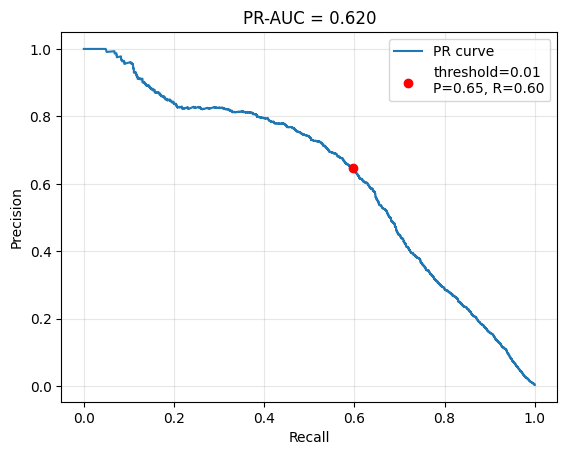

In [26]:
target_threshold = thresholds[best]
idx = np.argmin(np.abs(thresholds - target_threshold))                                                                                                                                                                                         
p_at, r_at = precision[idx], recall[idx]
                                                                                                                                                                                                                                                
plt.plot(recall, precision, label='PR curve')             
plt.scatter(r_at, p_at, color='red', zorder=5,                                                                                                                                                                                                 
            label=f'threshold={target_threshold:.2f}\nP={p_at:.2f}, R={r_at:.2f}')
plt.xlabel('Recall'); plt.ylabel('Precision')                                                                                                                                                                                                  
plt.title(f'PR-AUC = {average_precision_score(y_test, proba):.3f}')                                                                                                                                                                            
plt.legend(); plt.grid(alpha=0.3); plt.show() 

In [29]:
target_precision = 0.8
idx = np.where(precision >= target_precision)[0][0] # first index meeting target as p_r_curve returns arrays sorted by decreasing threshold
p_at, r_at, t_at = precision[idx], recall[idx], thresholds[idx]
print(f"At threshold={t_at:.3f}, precision={p_at:.3f} and recall={r_at:.3f}")

At threshold=0.257, precision=0.801 and recall=0.384


# Feature importance

In [ ]:
#   Feature importance                                                                                                                                                                                                                        
pd.Series(best_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

is_night               0.404083
amt                    0.287968
hour_cos               0.138920
category               0.036653
30d_spend_amt          0.021992
30d_num_tx             0.017892
city                   0.015038
hour                   0.011405
time_since_last_tx     0.008386
amt_vs_card_mean       0.006936
amt_vs_recent_spend    0.006454
age                    0.006440
hour_sin               0.004978
gender                 0.004770
city_pop               0.003610
dtype: float32

 Among the features XGBoost used, is_night had about 40.4% of the normalized average split gain.
 It means that when XGBoost used is_night to split a tree node, those splits produced very large average improvements in the training objective relative to other features.

In [31]:
best_clf.feature_importances_

array([0.00207502, 0.03665277, 0.28796777, 0.00476957, 0.01503846,
       0.00226073, 0.00253697, 0.00184759, 0.00206116, 0.00361002,
       0.00353525, 0.00189764, 0.00186698, 0.01140493, 0.00145863,
       0.00159306, 0.00643965, 0.00693615, 0.00838575, 0.0016946 ,
       0.02199203, 0.01789214, 0.0016494 , 0.00497774, 0.13891986,
       0.00645354, 0.40408263, 0.        , 0.        ], dtype=float32)

# Serving the model

In [32]:
import mlflow.pyfunc

class FraudModel(mlflow.pyfunc.PythonModel):
    def __init__(self, encoder, clf, cat_cols, threshold):
        self.encoder = encoder
        self.clf = clf
        self.cat_cols = cat_cols
        self.threshold = threshold

    def predict(self, context, model_input):
        X = model_input.copy()
        for c in self.cat_cols:
            X[c] = X[c].astype('category')
        X[self.cat_cols] = self.encoder.transform(X[self.cat_cols])
        proba = self.clf.predict_proba(X)[:, 1]
        return pd.DataFrame({
            "fraud_proba": proba,
            "fraud_flag": (proba >= self.threshold).astype(int),
        })

with mlflow.start_run(run_name="fraud_v1_production"):
    mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=FraudModel(encoder, best_clf, cat_cols, threshold=0.257),
        input_example=X_test.head(3),
        registered_model_name="fraud_xgb_block",
    )

.venv/lib/python3.14/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/05/11 10:07:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/11 10:07:01 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/05/11 10:07:01 INFO mlflow.pyfunc: Inferring model signature from input example
.venv/lib/python3.14/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred

🏃 View run fraud_v1_production at: http://localhost:5000/#/experiments/2/runs/832422e1dab447e081d17541187c1d44
🧪 View experiment at: http://localhost:5000/#/experiments/2


In [33]:
# mlflow models serve -m "models:/fraud_xgb_block@champion" -p 8000 --no-condaclear

# Running inference (i.e. invocations)

In [34]:
import requests                                                                                                                                                                                                                                     
import json                                                                                                                                                                                                                                         

# Build raw X_test (the wrapper does encoding internally, so feed it strings)                                                                                                                                                                       
drop_list = ['Unnamed: 0', 'cc_num', 'trans_num', 'street', 'first', 'last', 'dob', 'trans_date_trans_time', 'unix_time']                                                                                                                                                                                           
X_test_raw = test_fe.drop(columns=drop_list + ['is_fraud']).head(3)                                                                                                                                                                       

payload = {"dataframe_split": X_test_raw.to_dict(orient="split")}

response = requests.post("http://localhost:8000/invocations", headers={"Content-Type": "application/json"}, json=payload)
print(response.status_code)                                                                                                                                                                                                                       
print(response.json())

200
{'predictions': [{'fraud_proba': 3.9056183709362813e-07, 'fraud_flag': 0}, {'fraud_proba': 1.1541483047050605e-10, 'fraud_flag': 0}, {'fraud_proba': 3.2763081136977235e-09, 'fraud_flag': 0}]}


In [41]:
fake_fraud = pd.DataFrame([{                                                                                                                                                                                                                        
    'merchant': 'fraud_Rippin, Kub and Mann',
    'category': 'shopping_net',
    'amt': 1000000000,                                                                                                                                                                                                                                 
    'gender': 'M',                                      
    'city': 'Miami', 'state': 'FL', 'zip': 33101,                                                                                                                                                                                                   
    'lat': 25.7617, 'long': -80.1918, 'city_pop': 442241,                                                                                                                                                                                           
    'job': 'Engineer, manufacturing',                    
    'merch_lat': 40.7128, 'merch_long': -74.0060,  # NYC, 1700km from home                                                                                                                                                                          
    'hour': 3,                                                                                                                                                                                                                                      
    'dayofweek': 2,                                        
    'day': 14,                                                                                                                                                                                                                                      
    'age': 67.0,                                                                                                                                                                                                                                    
    'amt_vs_card_mean': 20000.0,         # 200x normal spend  
    'time_since_last_tx': 30,          # 30s since last tx                                                                                                                                                                                          
    'distance_from_prev': 5000,        # 5000km in 30s (physically impossible)                                                                                                                                                                      
    '30d_spend_amt': 50.0,             # tiny normal spend history
    '30d_num_tx': 3,                                                                                                                                                                                                                                
    'distance_from_home': 17000,        # 1700km from cardholder home
    'hour_sin': np.sin(2 * np.pi * 3 / 24),                                                                                                                                                                                                         
    'hour_cos': np.cos(2 * np.pi * 3 / 24),                                                                                                                                                                                                         
    'amt_vs_recent_spend': 200.0,                                    
    'is_night': 1,                                                                                                                                                                                                                                  
    '1h_num_tx': 4,                    # burst: 4 tx in last hour          
    'log_amt': np.log1p(9999.99),                                                                                                                                                                                                                   
}])                                                                           

response = requests.post(              
    "http://localhost:8000/invocations",
    json={"dataframe_split": fake_fraud.to_dict(orient="split")},
)
                                                                                                                                                                                                                                                
print(response.json()) 

{'predictions': [{'fraud_proba': 0.033816851675510406, 'fraud_flag': 0}]}
